       Country ISO3      W     E      V      S      C      A   S_01   S_02  \
0  Afghanistan  AFG   4.19  0.25  70.32  61.91  78.59  71.47  65.90  70.66   
1      Albania  ALB   6.53  2.38  17.94  12.58  44.15  10.40  53.08  15.47   
2      Algeria  DZA  10.29  2.65  39.94  30.07  51.99  40.76  48.02  35.44   
3      Andorra  AND   0.32  0.02   5.21   2.58   2.18  25.10  33.23   0.54   
4       Angola  AGO  11.06  2.18  56.09  35.52  65.02  76.41  59.61  64.24   

   ...  AI_04a_Norm  AI_04a_Base  AI_04b_Norm  AI_04b_Base  AI_04c_Norm  \
0  ...       100.00           24        91.54           24        92.31   
1  ...        19.61           97        19.81           97        25.19   
2  ...        40.23           86        42.01           86        43.75   
3  ...        12.85           98        27.52           95        37.18   
4  ...        84.23           31       100.00           21        80.24   

   AI_04c_Base  AI_05a_Norm  AI_05a_Base  AI_05b_Norm  AI_05b_Base  
0          

/tmp/ipykernel_1917925/3791717603.py:20: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


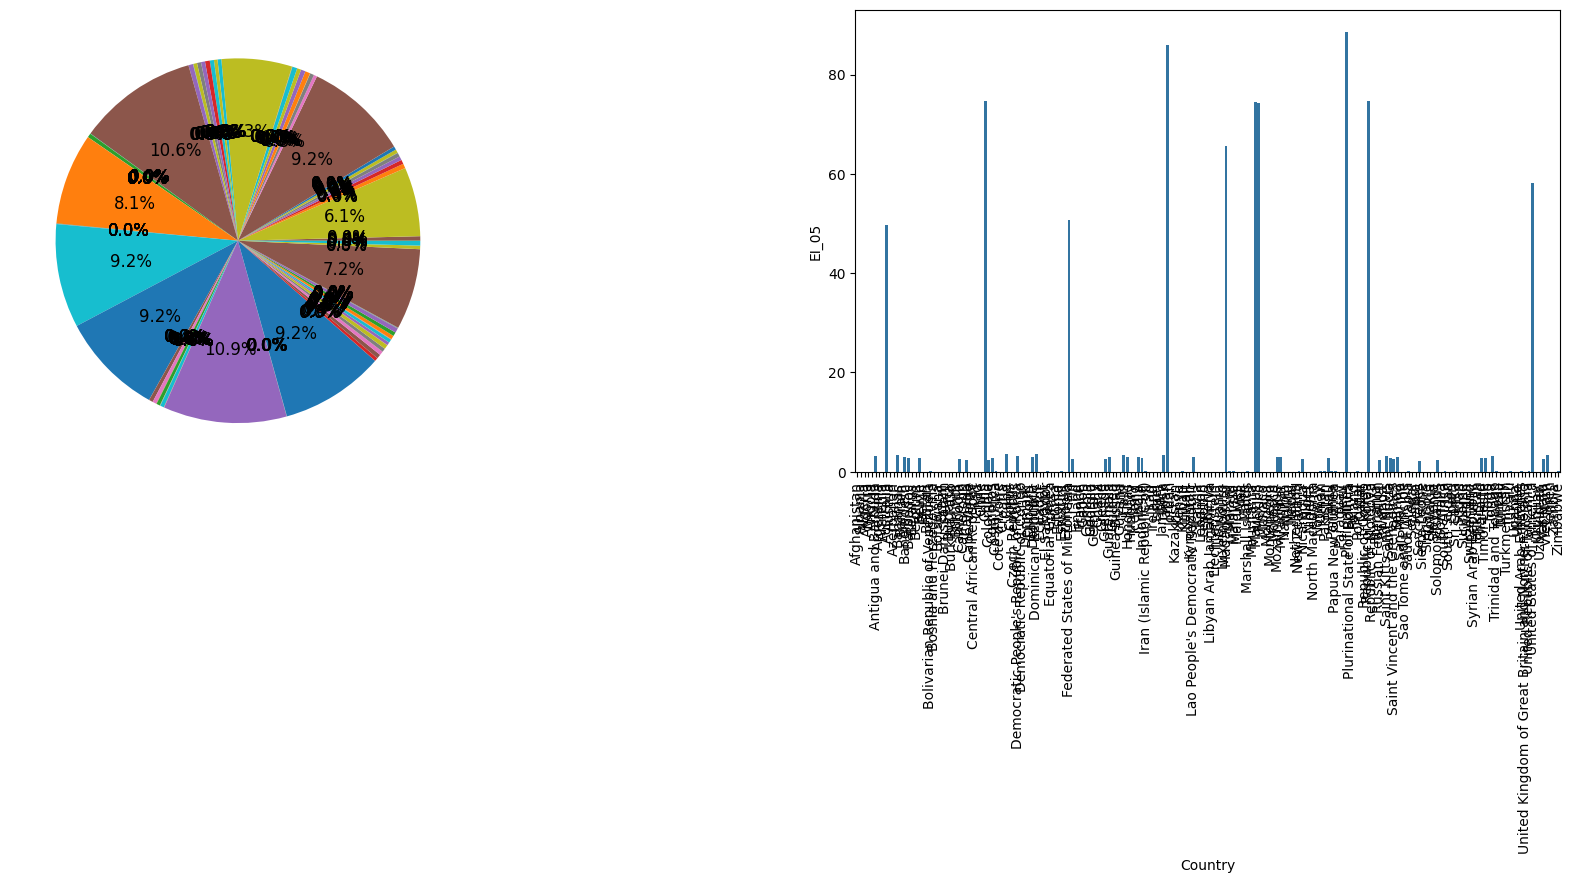

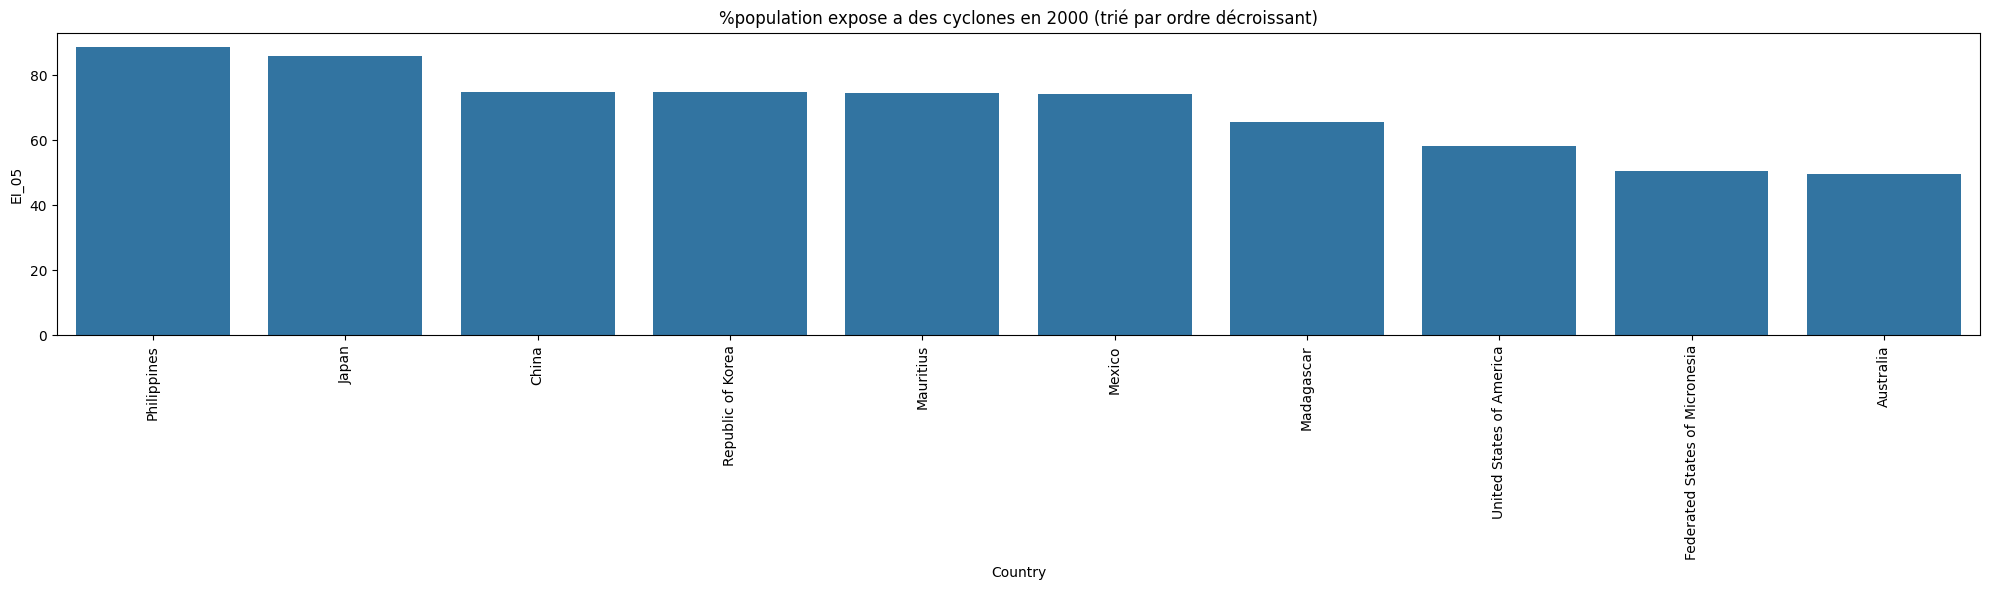

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('year_data/worldriskindex-2000.csv')
print(data.head())

plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
plt.pie(data.groupby('Country')['EI_05'].sum(), autopct='%1.1f%%', textprops={'fontsize':12})
plt.title('')

#difficile de représenter plus de 100 pays...

plt.subplot(1,2,2)
sns.barplot(x='Country', y='EI_05', data=data, estimator=sum)
plt.xticks(rotation=90)
plt.title('')
plt.tight_layout()
plt.show()

#mais si on retire les lignes trop faibles ?

data_non_zero = data[data['EI_05'] > 5]

# et qu'on trie par ordre décroissant ?
data_non_zero_sorted = data_non_zero.groupby('Country')['EI_05'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(20,6))
sns.barplot(x='Country', y='EI_05', data=data_non_zero_sorted, estimator=sum)
plt.xticks(rotation=90)
plt.title('%population expose a des cyclones en 2000 (trié par ordre décroissant)')
plt.tight_layout()
plt.show()

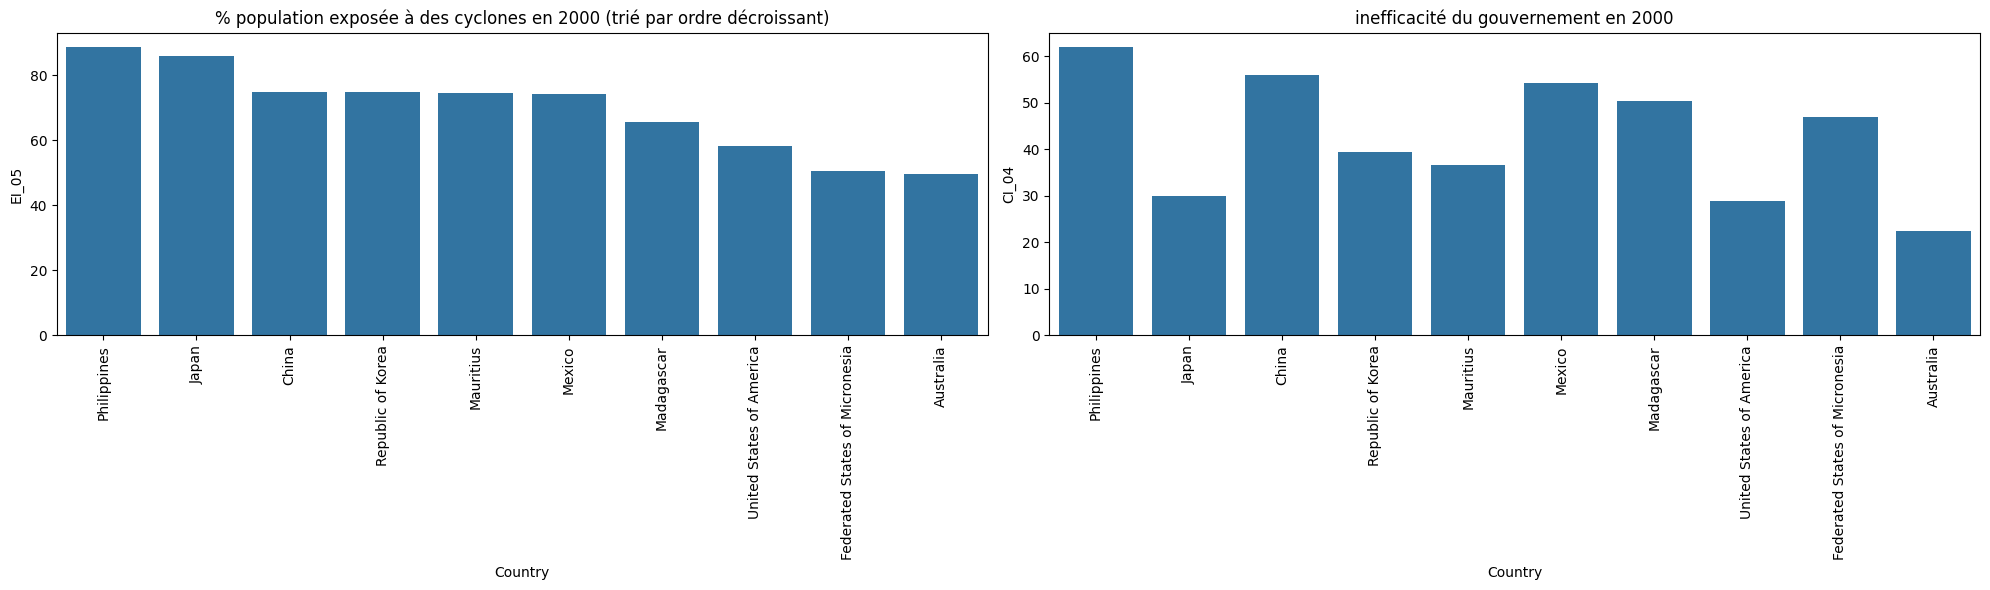

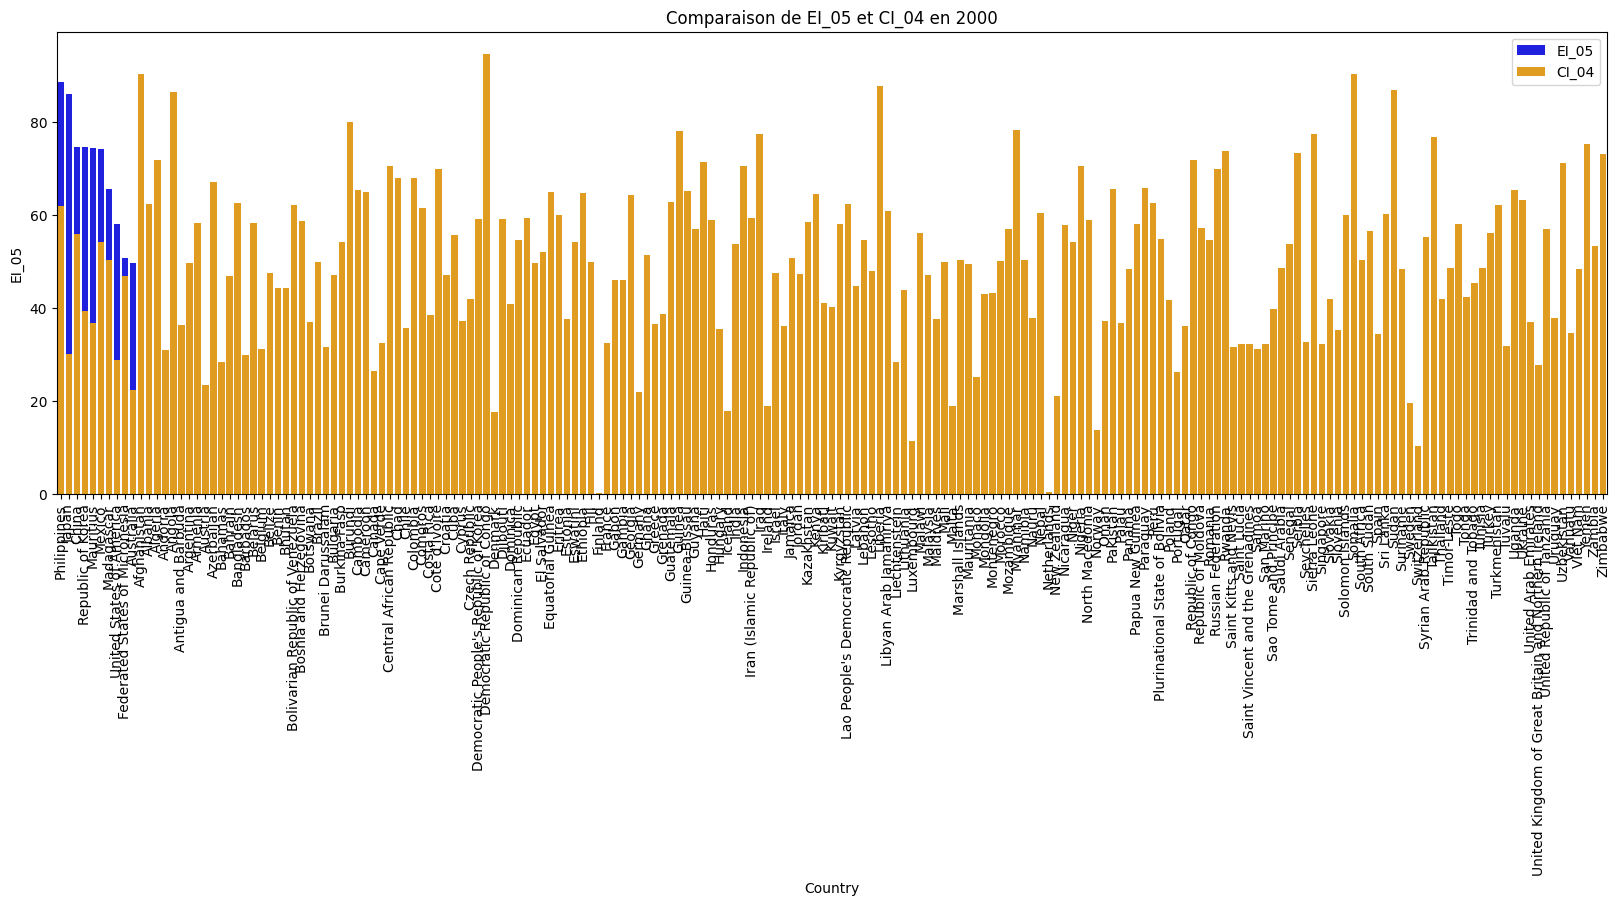

In [2]:

#maintenant on conpare avec CI_04.
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.barplot(x='Country', y='EI_05', data=data_non_zero_sorted, estimator=sum)
plt.xticks(rotation=90)
plt.title('% population exposée à des cyclones en 2000 (trié par ordre décroissant)')
plt.subplot(1,2,2)
data_filtered = data.nlargest(10, columns='EI_05')
sns.barplot(x='Country', y='CI_04', data=data_filtered, estimator=sum)
plt.xticks(rotation=90)
plt.title('inefficacité du gouvernement en 2000')
plt.tight_layout()
plt.show()

#mais dans un seul graphique
plt.figure(figsize=(20,6))
sns.barplot(x='Country', y='EI_05', data=data_non_zero_sorted, estimator=sum, color='blue', label='EI_05')
sns.barplot(x='Country', y='CI_04', data=data, estimator=sum, color='orange', label='CI_04')
plt.xticks(rotation=90)
plt.title('Comparaison de EI_05 et CI_04 en 2000')
plt.legend()


In [3]:
# todo :
# propos général : part de la population touchée (nombre et %) (+queantité de population déplacé en conséquence) (+ nbr de catastrophes ?) et evolution ds le temps.
# Focus par zone géographique. (rassembler les pays par régions)
# lier à un autre jeu de données pour comparer les caracteristiques du pays et les conséquences des catastrophes. (nbr mort, pertes économiques, ...)
# focus sur les pays les plus/moins vulnérables/exposés, quel sont leurs points communs ? (gouvernement ?, niveau de développement ?, système éducatif ?, immigration ? ...)
# Un passage sur les risques non humains ? (zones de forets brulés (nbr hectare par pays), baisse biodiversité (nbr espèces ?), ...)
# si on veut creuser plus : pollution, exportations, aides internationales.